# A two-sector I-HANK model with Present Bias

**Table of contents**<a id='toc0_'></a>    
- 1. [Setup](#toc1_)    
- 2. [Steady state](#toc2_)    
- 3. [Compute Jacobians](#toc3_)    
- 4. [Foreign demand shock](#toc4_)    
- 5. [Response in consumption to different shocks](#toc5_)    
- 6. [Decomposing consumption response](#toc6_)    
- 7. [Fixed vs floating exchange rate](#toc7_)    
- 8. [Decomposing consumption response under fixed exchange rate](#toc8_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

import matplotlib.pyplot as plt   
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({"axes.grid" : True, "grid.color": "black", "grid.alpha":"0.25", "grid.linestyle": "--"})
plt.rcParams.update({'font.size': 14})

from IHANKModel import IHANKModelClass

## 1. <a id='toc1_'></a>[Setup](#toc0_)

In [2]:
model = IHANKModelClass(name='baseline')

In [3]:
model.info()

settings:
 par.py_hh = False
 par.py_blocks = False
 par.full_z_trans = False
 par.warnings = True
 par.T = 500

households:
 grids_hh: [a]
 pols_hh: [a]
 inputs_hh: [beta,ra,inc_TH,inc_NT]
 inputs_hh_z: []
 outputs_hh: [a,c,uc_TH,uc_NT,c_TH,c_NT]
 intertemps_hh: [vbeg_a]

aggregate:
 shocks: [ZTH,ZNT,M_s,rF,PF_s,beta,G,i_shock]
 unknowns: [CB,NNT,NTH,piWTH,piWNT]
 targets: [NKWCT_res,NKWCNT_res,clearing_YTH,clearing_YNT,UIP_res]

blocks (inputs -> outputs):
 mon_pol: [CB] -> [E]
 production: [ZTH,ZNT,NTH,NNT,piWTH,piWNT] -> [YTH,YNT,WTH,WNT,PTH,PNT]
 prices: [PF_s,E,PTH,PNT,WTH,WNT] -> [PF,PTH_s,PT,P,Q,wTH,wNT]
 inflation: [PF_s,PF,PNT,PTH,PT,P,PTH_s] -> [pi_F_s,pi_F,pi_NT,pi_TH,pi_T,pi,pi_TH_s]
 central_bank: [pi,E,i_shock,CB] -> [i,r,ra]
 government: [PNT,P,wTH,NTH,wNT,NNT,ra,G] -> [B,tau,inc_TH,inc_NT]
 hh: [beta,inc_NT,inc_TH,ra] -> [A_hh,C_hh,UC_TH_hh,UC_NT_hh,C_TH_hh,C_NT_hh]
 NKWCs: [beta,piWTH,piWNT,NTH,NNT,wTH,wNT,tau,UC_TH_hh,UC_NT_hh] -> [NKWCT_res,NKWCNT_res]
 UIP: [Q,r,rF

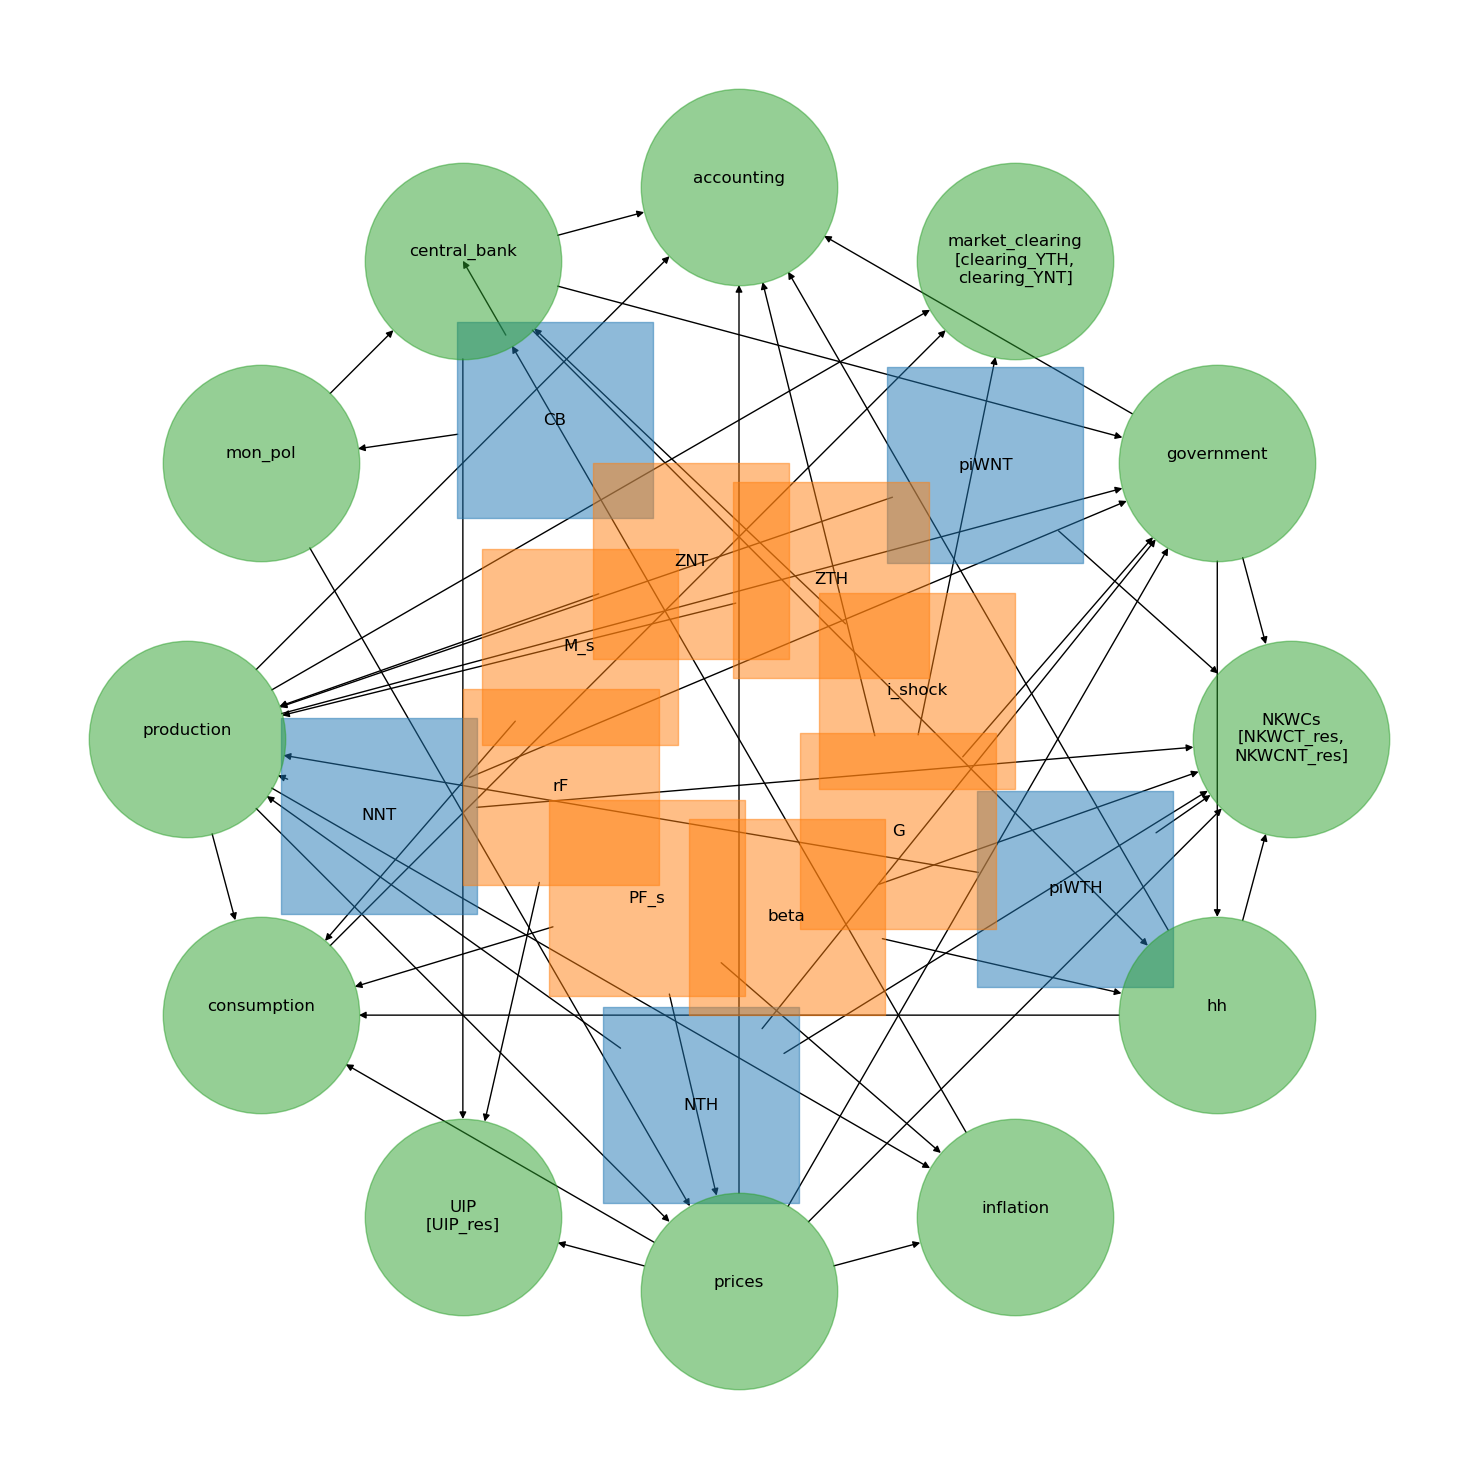

In [4]:
model.draw_DAG(figsize=(15,15),order=['shocks','unknowns','blocks'])

In [5]:
par = model.par
ss = model.ss
path = model.path
sim = model.sim

## 2. <a id='toc2_'></a>[Steady state](#toc0_)

In [6]:
model.find_ss(do_print=True)

household problem in ss solved in 8.0 secs [377 iterations]
household problem in ss simulated in 4.4 secs [406 iterations]
steady state found in 13.2 secs
ss.inc_TH = 0.175
ss.inc_NT = 0.525
par.alphaT = 0.356
par.alphaF = 0.333
par.varphiTH = 1.295
par.varphiNT = 1.295
ss.M_s = 0.083
ss.clearing_YTH =   0.00000000
ss.clearing_YNT =   0.00000000
ss.G = 0.298
ss.NFA = 0.000


In [7]:
model.test_ss()

E              :       1.0000
CB             :       0.0050
ZTH            :       1.0000
ZNT            :       1.0000
NTH            :       0.2500
NNT            :       0.7500
piWTH          :       0.0000
piWNT          :       0.0000
YTH            :       0.2500
YNT            :       0.7500
WTH            :       1.0000
WNT            :       1.0000
PTH            :       1.0000
PNT            :       1.0000
PF_s           :       1.0000
PF             :       1.0000
PTH_s          :       1.0000
PT             :       1.0000
P              :       1.0000
Q              :       1.0000
wTH            :       1.0000
wNT            :       1.0000
pi_F_s         :       0.0000
pi_F           :       0.0000
pi_NT          :       0.0000
pi_TH          :       0.0000
pi_T           :       0.0000
pi             :       0.0000
pi_TH_s        :       0.0000
i              :       0.0050
r              :       0.0050
ra             :       0.0050
i_shock        :       0.0000
G         

In [8]:
MPC = np.sum(ss.D[:,:,:-1]*(ss.c[:,:,1:]-ss.c[:,:,:-1])/((1+ss.r)*(par.a_grid[1:]-par.a_grid[:-1])))
print(f'{MPC:.2f}')

0.65


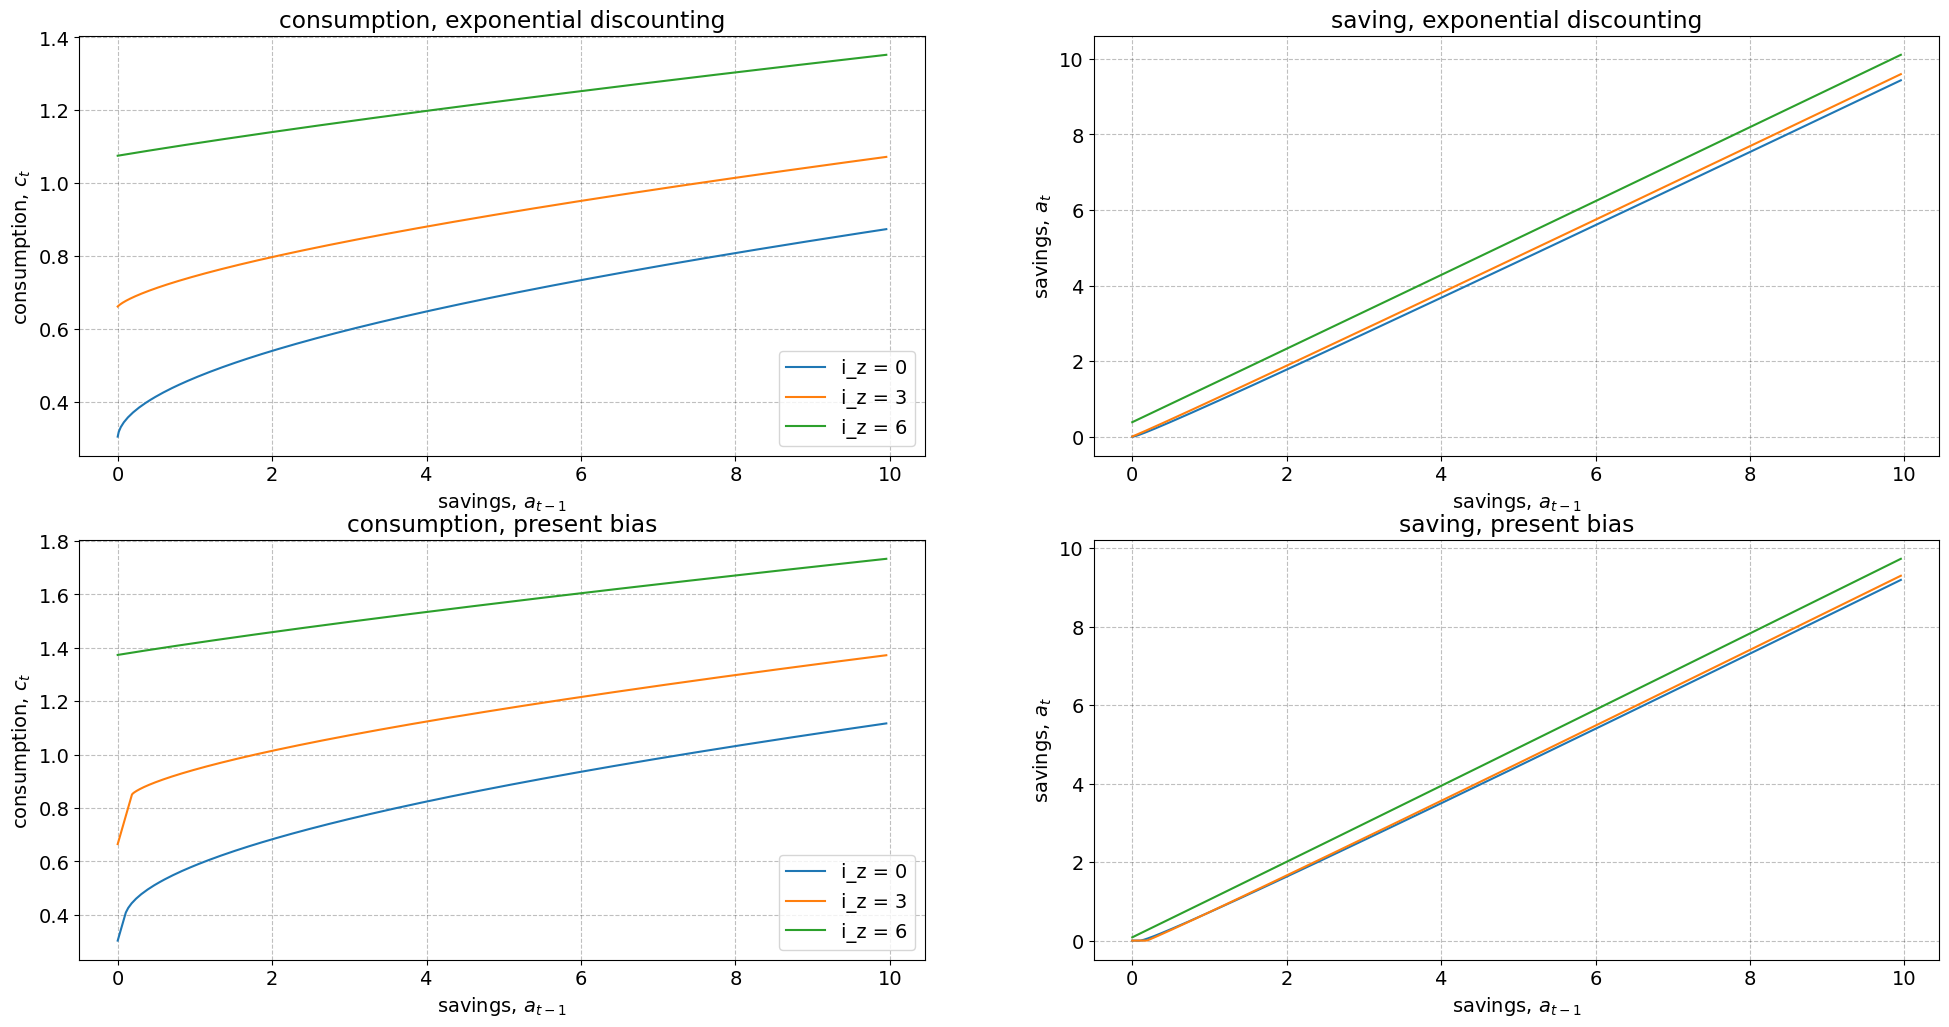

In [9]:
fig = plt.figure(figsize=(24,12),dpi=100)
a_max = 10

# a. consumption, without present bias
I = par.a_grid < a_max

ax = fig.add_subplot(2,2,1)
ax.set_title(f'consumption, exponential discounting')


for i_z in [0,par.Nz//2,par.Nz-1]:
    ax.plot(par.a_grid[I],ss.c[0,i_z,I],label=f'i_z = {i_z}')

ax.legend(frameon=True)
ax.set_xlabel('savings, $a_{t-1}$')
ax.set_ylabel('consumption, $c_t$')

# b. saving, without present bias
I = par.a_grid < a_max

ax = fig.add_subplot(2,2,2)
ax.set_title(f'saving, exponential discounting')

for i_z in [0,par.Nz//2,par.Nz-1]:
    ax.plot(par.a_grid[I],ss.a[0,i_z,I],label=f'i_z = {i_z}')

ax.set_xlabel('savings, $a_{t-1}$')
ax.set_ylabel('savings, $a_{t}$')

# c. consumption, with present bias
I = par.a_grid < a_max

ax = fig.add_subplot(2,2,3)
ax.set_title(f'consumption, present bias')

for i_z in [0,par.Nz//2,par.Nz-1]:
    ax.plot(par.a_grid[I],ss.c[1,i_z,I],label=f'i_z = {i_z}')

ax.legend(frameon=True)
ax.set_xlabel('savings, $a_{t-1}$')
ax.set_ylabel('consumption, $c_t$')

# d. saving, with present bias
I = par.a_grid < a_max

ax = fig.add_subplot(2,2,4)
ax.set_title(f'saving, present bias')

for i_z in [0,par.Nz//2,par.Nz-1]:
    ax.plot(par.a_grid[I],ss.a[1,i_z,I],label=f'i_z = {i_z}')

ax.set_xlabel('savings, $a_{t-1}$')
ax.set_ylabel('savings, $a_{t}$')


plt.show()

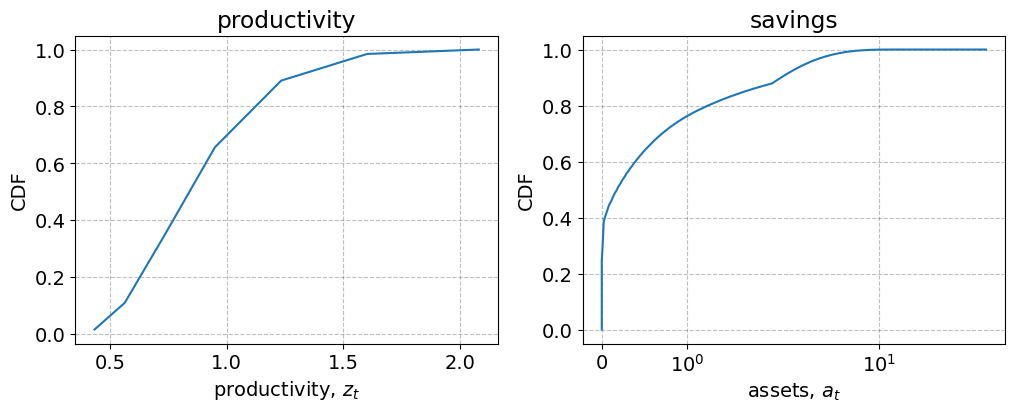

In [10]:
fig = plt.figure(figsize=(12,4),dpi=100)

# a. income
ax = fig.add_subplot(1,2,1)
ax.set_title('productivity')

y = np.cumsum(np.sum(ss.D[0],axis=1))
ax.plot(par.z_grid,y/y[-1])

ax.set_xlabel('productivity, $z_{t}$')
ax.set_ylabel('CDF')

# b. assets
ax = fig.add_subplot(1,2,2)
ax.set_title('savings')
y = np.insert(np.cumsum(np.sum(ss.D[0],axis=0)),0,0.0)
ax.plot(np.insert(par.a_grid,0,par.a_grid[0]),y/y[-1])
        
ax.set_xlabel('assets, $a_{t}$')
ax.set_ylabel('CDF')
ax.set_xscale('symlog')

## 3. <a id='toc3_'></a>[Compute Jacobians](#toc0_)

**Household transition path:**

note: inputs = steady state value -> expected: constant value (straigt line)

household problem solved along transition path in 2.2 secs
household problem simulated along transition in 3.2 secs



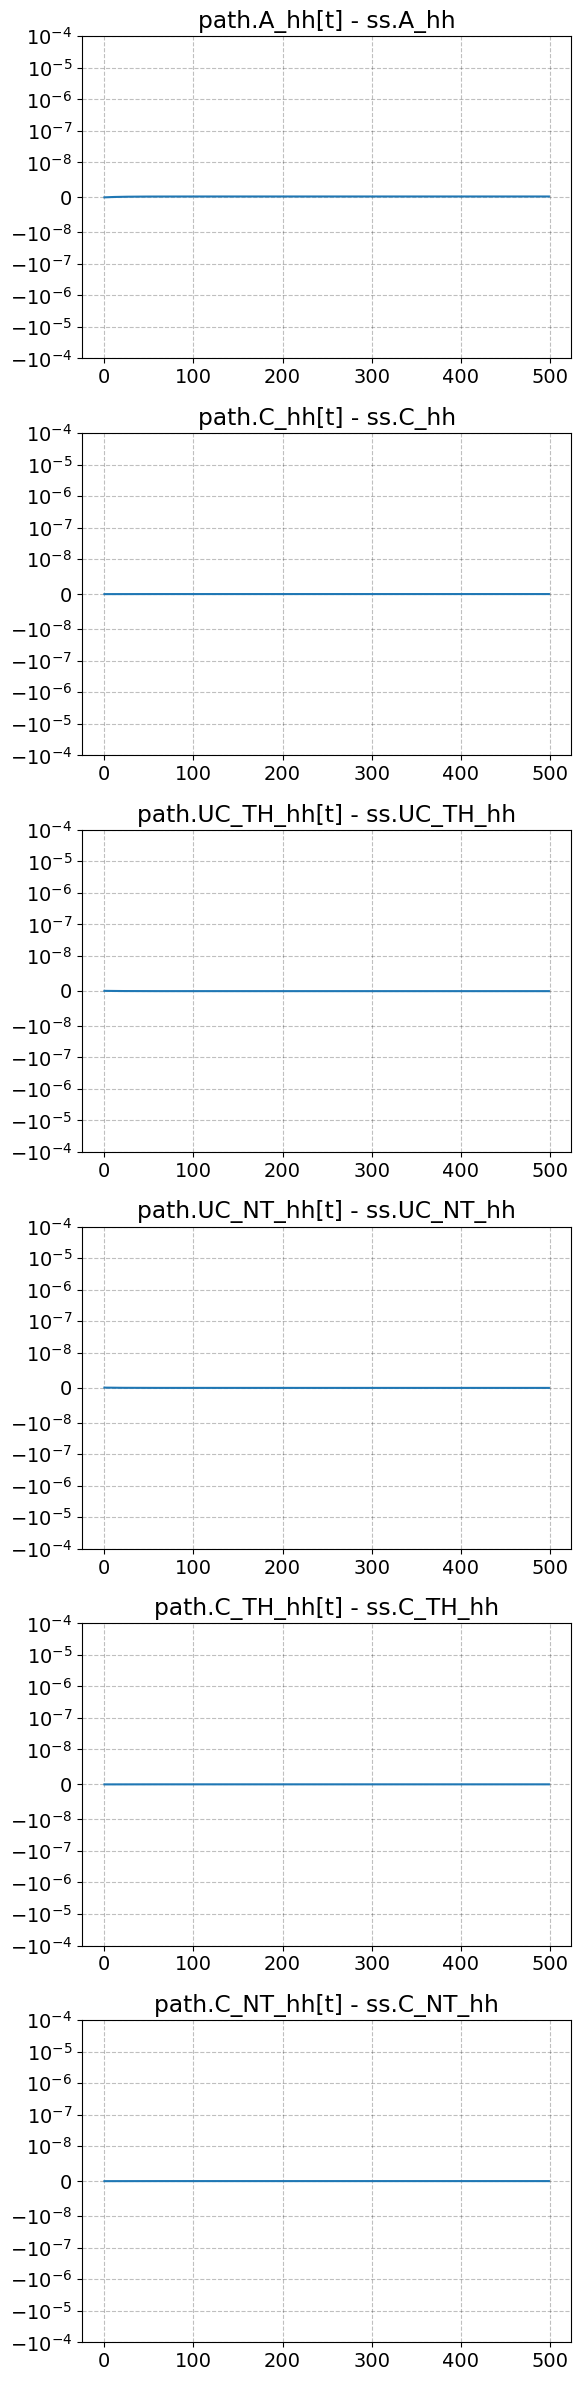

In [11]:
model.test_hh_path()

**Full transition path:**

In [12]:
model.test_path()

shocks: ZTH ZNT M_s rF PF_s beta G i_shock 
unknowns: CB NNT NTH piWTH piWNT 

blocks.mon_pol
 E                0.0e+00
blocks.production
 YTH              0.0e+00
 YNT              0.0e+00
 WTH              0.0e+00
 WNT              0.0e+00
 PTH              0.0e+00
 PNT              0.0e+00
blocks.prices
 PF               0.0e+00
 PTH_s            0.0e+00
 PT               0.0e+00
 P                0.0e+00
 Q                0.0e+00
 wTH              0.0e+00
 wNT              0.0e+00
blocks.inflation
 pi_F_s           0.0e+00
 pi_F             0.0e+00
 pi_NT            0.0e+00
 pi_TH            0.0e+00
 pi_T             0.0e+00
 pi               0.0e+00
 pi_TH_s          0.0e+00
blocks.central_bank
 i                0.0e+00
 r                1.1e-16
 ra               1.1e-16
blocks.government
 B                5.6e-17
 tau              0.0e+00
 inc_TH           0.0e+00
 inc_NT           0.0e+00
hh
 A_hh             2.5e-10
 C_hh             1.4e-11
 UC_TH_hh         7.7e-11
 UC_NT_hh 

**Jacobians:**

In [13]:
model.compute_jacs(do_print=True)

household Jacobians:
one step deviation from steady state calculated in 0.0 secs
curly_Y and curly_D calculated for beta            in 2.4 secs
curly_Y and curly_D calculated for inc_NT          in 3.3 secs
curly_Y and curly_D calculated for inc_TH          in 2.4 secs
curly_Y and curly_D calculated for ra              in 3.2 secs
curly_E calculated in 3.4 secs
builiding blocks combined in 3.5 secs
household Jacobian computed in 18.4 secs

full Jacobians:
full Jacobian to unknowns computed in 3.8 secs [in evaluate_blocks(): 1.6 secs]
full Jacobian to shocks computed in 5.8 secs [in evaluate_blocks(): 2.4 secs]


## 4. <a id='toc4_'></a>[Foreign demand shock](#toc0_)

In [14]:
par.jump_M_s = -0.0075 # initial jump
par.rho_M_s = 0.80 # AR(1) coefficeint

par.jump_rF = -0.00005 # initial jump
par.rho_rF = 0.80 # AR(1) coefficeint

par.jump_PF_s = -0.03 # initial jump
par.rho_PF_s = 0.80 # AR(1) coefficeint

model.find_transition_path(shocks=['M_s','rF','PF_s'],do_print=True,do_end_check=False)

finding the transition path:
 it =   0 -> max. abs. error = 1.27e-02
   3.74e-04 in NKWCT_res
   3.74e-04 in NKWCNT_res
   1.27e-02 in clearing_YTH
   1.91e-03 in clearing_YNT
   6.16e-03 in UIP_res
 it =   1 -> max. abs. error = 5.63e-04
   5.63e-04 in NKWCT_res
   6.66e-05 in NKWCNT_res
   3.82e-04 in clearing_YTH
   5.55e-05 in clearing_YNT
   1.31e-04 in UIP_res
 it =   2 -> max. abs. error = 8.96e-06
   6.90e-06 in NKWCT_res
   8.20e-07 in NKWCNT_res
   8.96e-06 in clearing_YTH
   4.31e-06 in clearing_YNT
   4.87e-06 in UIP_res
 it =   3 -> max. abs. error = 1.65e-07
   1.65e-07 in NKWCT_res
   3.15e-08 in NKWCNT_res
   4.52e-08 in clearing_YTH
   5.04e-08 in clearing_YNT
   2.04e-08 in UIP_res
 it =   4 -> max. abs. error = 2.81e-09
   2.81e-09 in NKWCT_res
   4.66e-10 in NKWCNT_res
   6.80e-10 in clearing_YTH
   4.95e-10 in clearing_YNT
   2.88e-10 in UIP_res
 it =   5 -> max. abs. error = 1.03e-10
   1.03e-10 in NKWCT_res
   6.50e-12 in NKWCNT_res
   1.00e-11 in clearing_YTH
  

### shocks ###


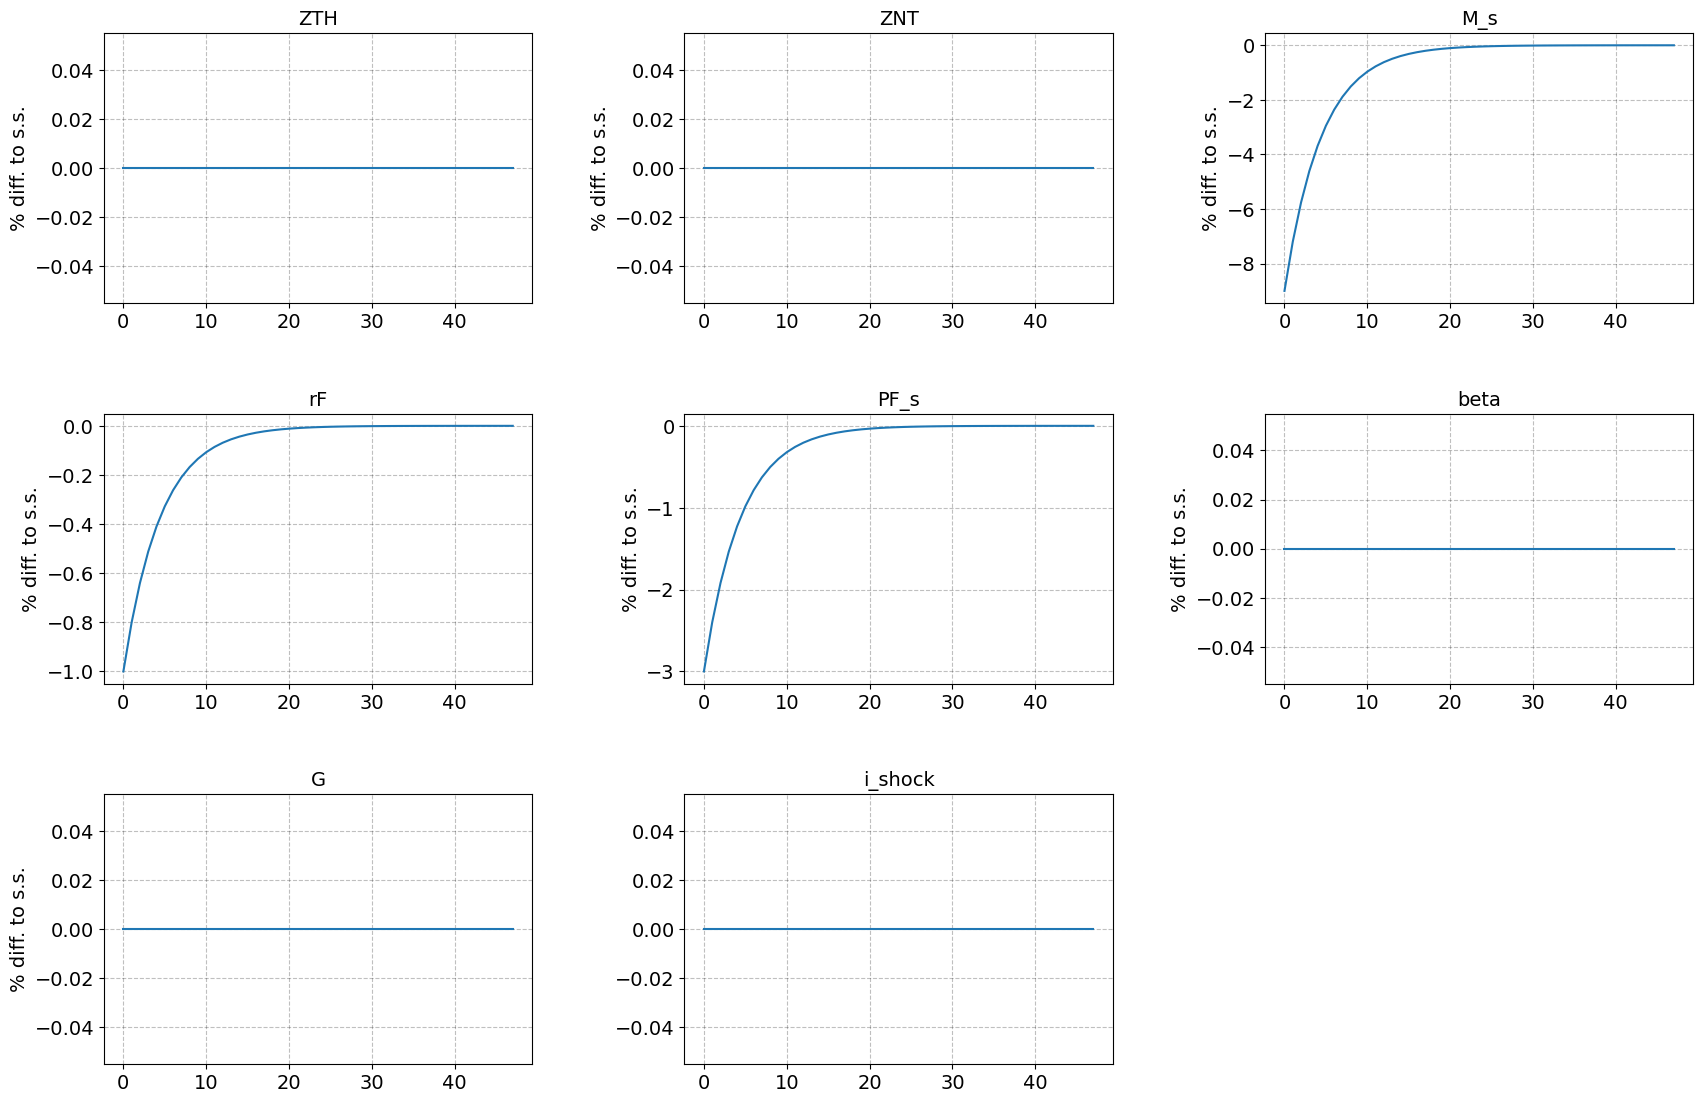


### varnames ###


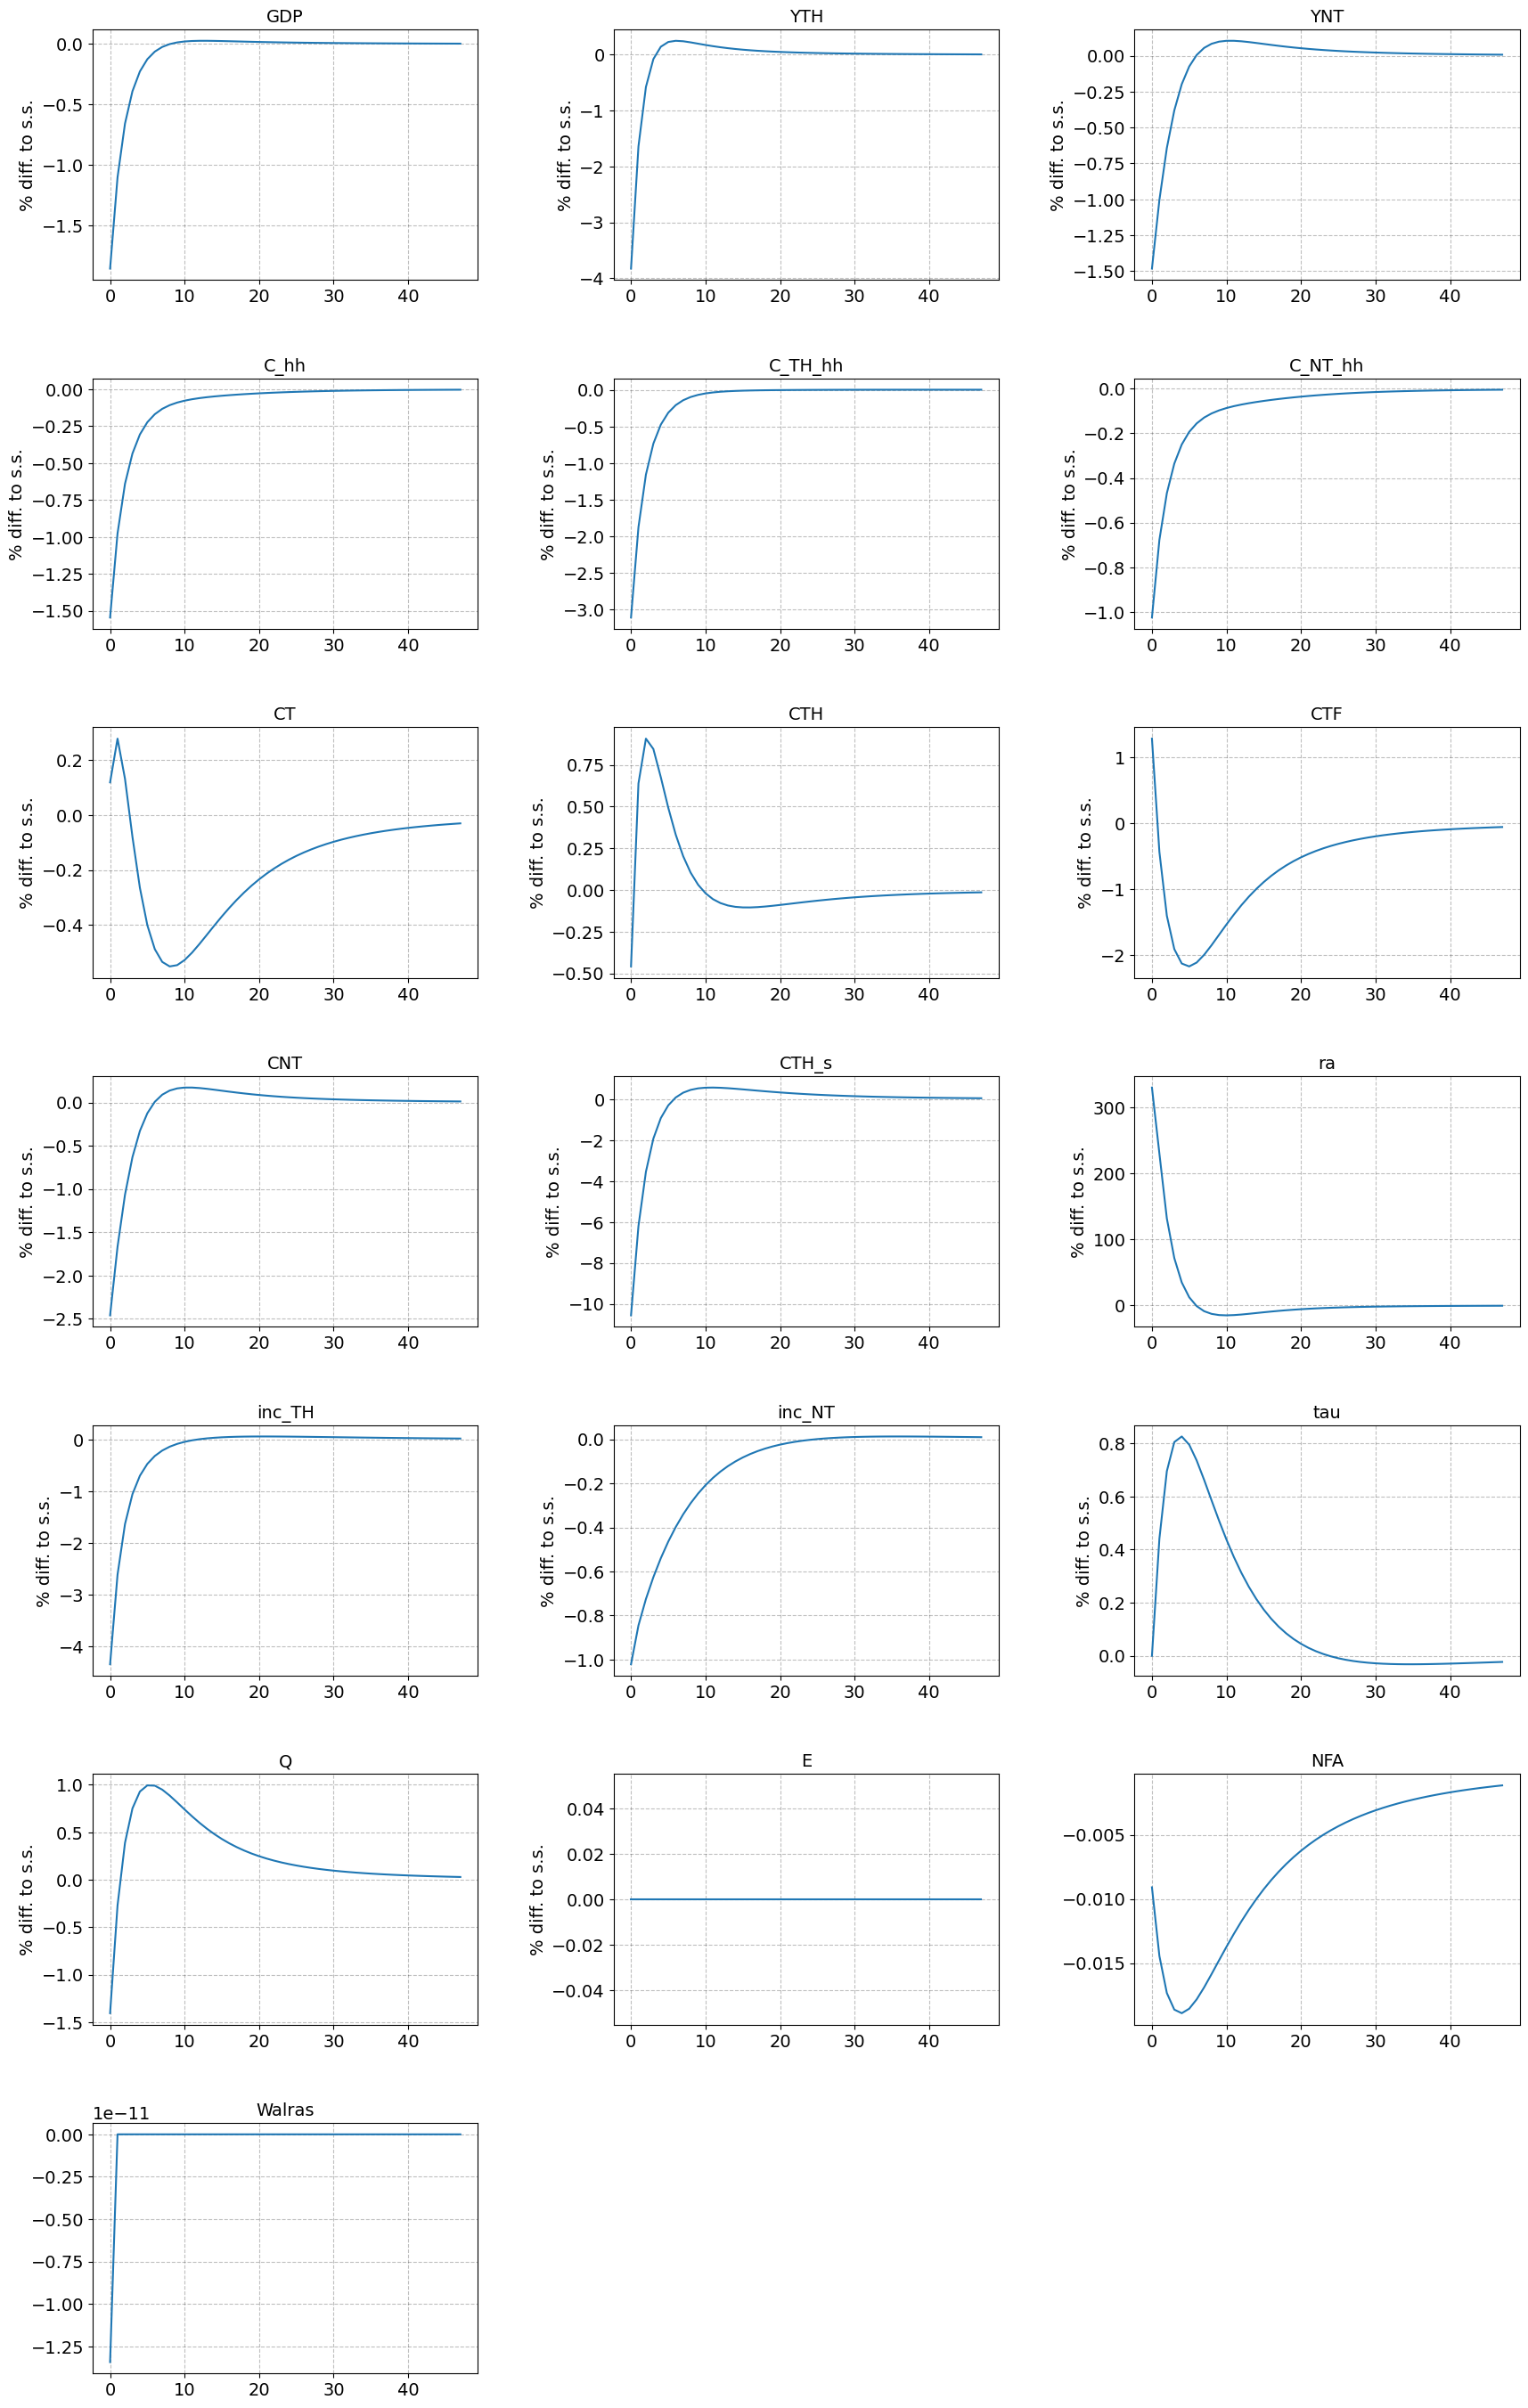


### tagets ###


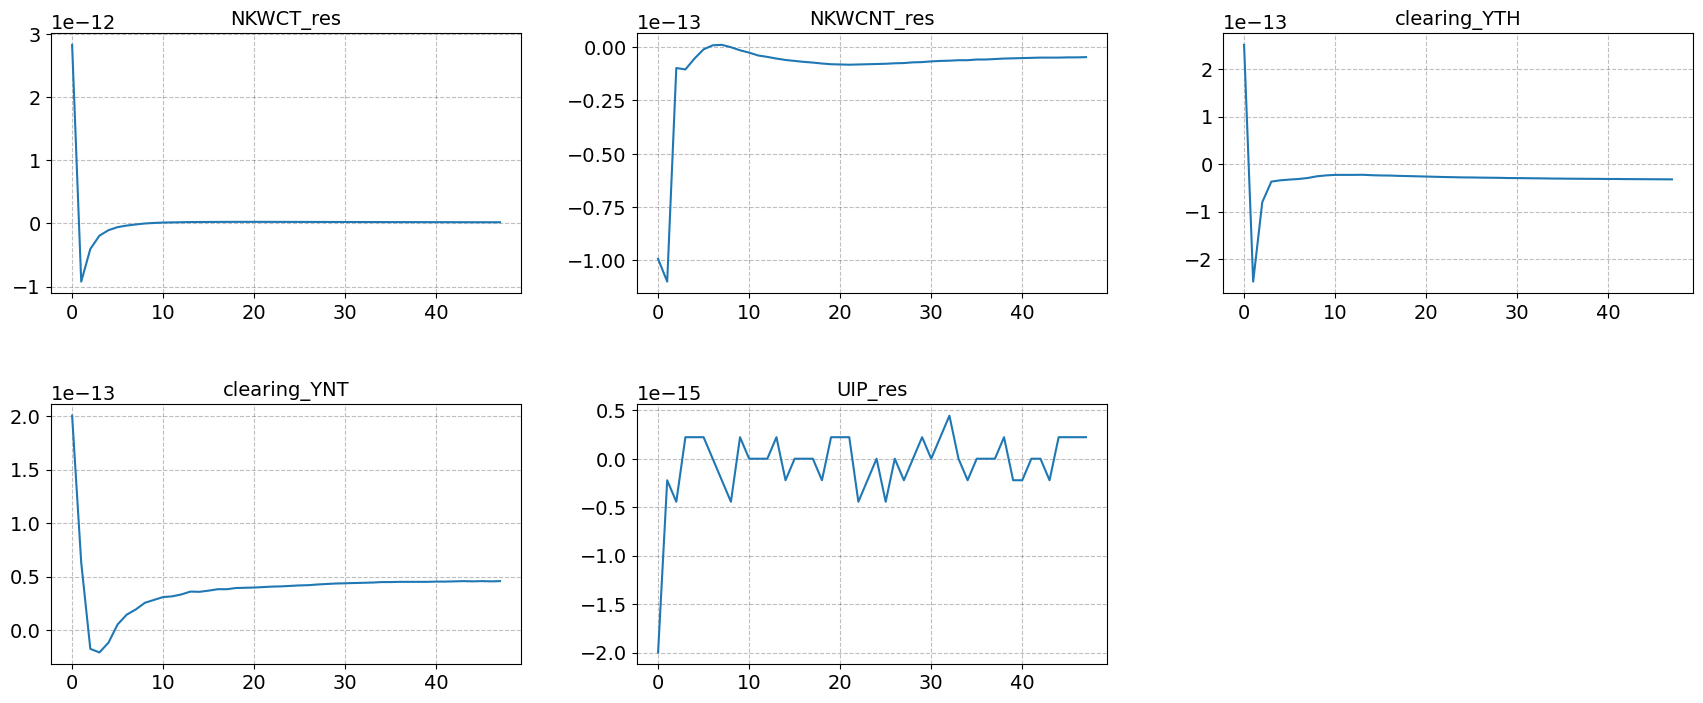

In [15]:
paths = ['GDP','YTH','YNT','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CNT','CTH_s','ra','inc_TH','inc_NT','tau','Q','E','NFA','Walras']
lvl_value=['r','NFA','Walras','i_shock']
model.show_IRFs(paths,lvl_value=lvl_value,T_max=48,ncols=3)

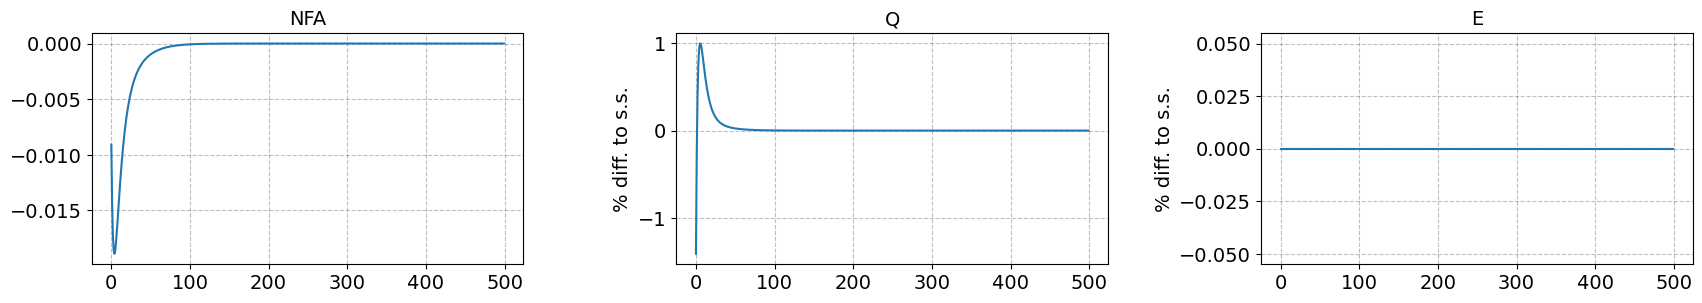

In [16]:
model.show_IRFs(['NFA','Q','E'],lvl_value=lvl_value,T_max=500,ncols=3,do_shocks=False,do_targets=False)

Without present bias:

In [19]:
ExpoDisc = model.copy()
ExpoDisc.par.delta = 1.0

ExpoDisc.find_ss(do_print=True)
ExpoDisc.compute_jacs(do_print=True)

ExpoDisc.par.jump_M_s = -0.0075 # initial jump
ExpoDisc.par.rho_M_s = 0.80 # AR(1) coefficeint

ExpoDisc.par.jump_rF = -0.00005 # initial jump
ExpoDisc.par.rho_rF = 0.80 # AR(1) coefficeint

ExpoDisc.par.jump_PF_s = -0.03 # initial jump
ExpoDisc.par.rho_PF_s = 0.80 # AR(1) coefficeint

ExpoDisc.find_transition_path(shocks=['M_s','rF','PF_s'],do_print=True,do_end_check=False)

household problem in ss solved in 1.0 secs [375 iterations]
household problem in ss simulated in 0.1 secs [406 iterations]
steady state found in 1.1 secs
ss.inc_TH = 0.175
ss.inc_NT = 0.525
par.alphaT = 0.355
par.alphaF = 0.333
par.varphiTH = 1.271
par.varphiNT = 1.271
ss.M_s = 0.083
ss.clearing_YTH =   0.00000000
ss.clearing_YNT =  -0.00000000
ss.G = 0.296
ss.NFA = 0.000
household Jacobians:
one step deviation from steady state calculated in 0.0 secs
curly_Y and curly_D calculated for beta            in 2.2 secs
curly_Y and curly_D calculated for inc_NT          in 2.9 secs
curly_Y and curly_D calculated for inc_TH          in 3.7 secs
curly_Y and curly_D calculated for ra              in 2.6 secs
curly_E calculated in 2.2 secs
builiding blocks combined in 3.5 secs
household Jacobian computed in 17.0 secs

full Jacobians:
full Jacobian to unknowns computed in 5.1 secs [in evaluate_blocks(): 2.4 secs]
full Jacobian to shocks computed in 8.2 secs [in evaluate_blocks(): 3.9 secs]
finding

In [20]:
PBsmall = model.copy()
PBsmall.par.delta = 0.9

PBsmall.find_ss(do_print=True)
PBsmall.compute_jacs(do_print=True)

PBsmall.par.jump_M_s = -0.0075 # initial jump
PBsmall.par.rho_M_s = 0.80 # AR(1) coefficeint

PBsmall.par.jump_rF = -0.00005 # initial jump
PBsmall.par.rho_rF = 0.80 # AR(1) coefficeint

PBsmall.par.jump_PF_s = -0.03 # initial jump
PBsmall.par.rho_PF_s = 0.80 # AR(1) coefficeint

PBsmall.find_transition_path(shocks=['M_s','rF','PF_s'],do_print=True,do_end_check=False)

household problem in ss solved in 1.1 secs [375 iterations]
household problem in ss simulated in 0.1 secs [406 iterations]
steady state found in 1.3 secs
ss.inc_TH = 0.175
ss.inc_NT = 0.525
par.alphaT = 0.356
par.alphaF = 0.333
par.varphiTH = 1.282
par.varphiNT = 1.282
ss.M_s = 0.083
ss.clearing_YTH =   0.00000000
ss.clearing_YNT =   0.00000000
ss.G = 0.297
ss.NFA = 0.000
household Jacobians:
one step deviation from steady state calculated in 0.0 secs
curly_Y and curly_D calculated for beta            in 3.1 secs
curly_Y and curly_D calculated for inc_NT          in 2.7 secs
curly_Y and curly_D calculated for inc_TH          in 3.5 secs
curly_Y and curly_D calculated for ra              in 4.3 secs
curly_E calculated in 0.9 secs
builiding blocks combined in 4.2 secs
household Jacobian computed in 18.9 secs

full Jacobians:
full Jacobian to unknowns computed in 7.4 secs [in evaluate_blocks(): 2.4 secs]
full Jacobian to shocks computed in 6.5 secs [in evaluate_blocks(): 2.8 secs]
finding

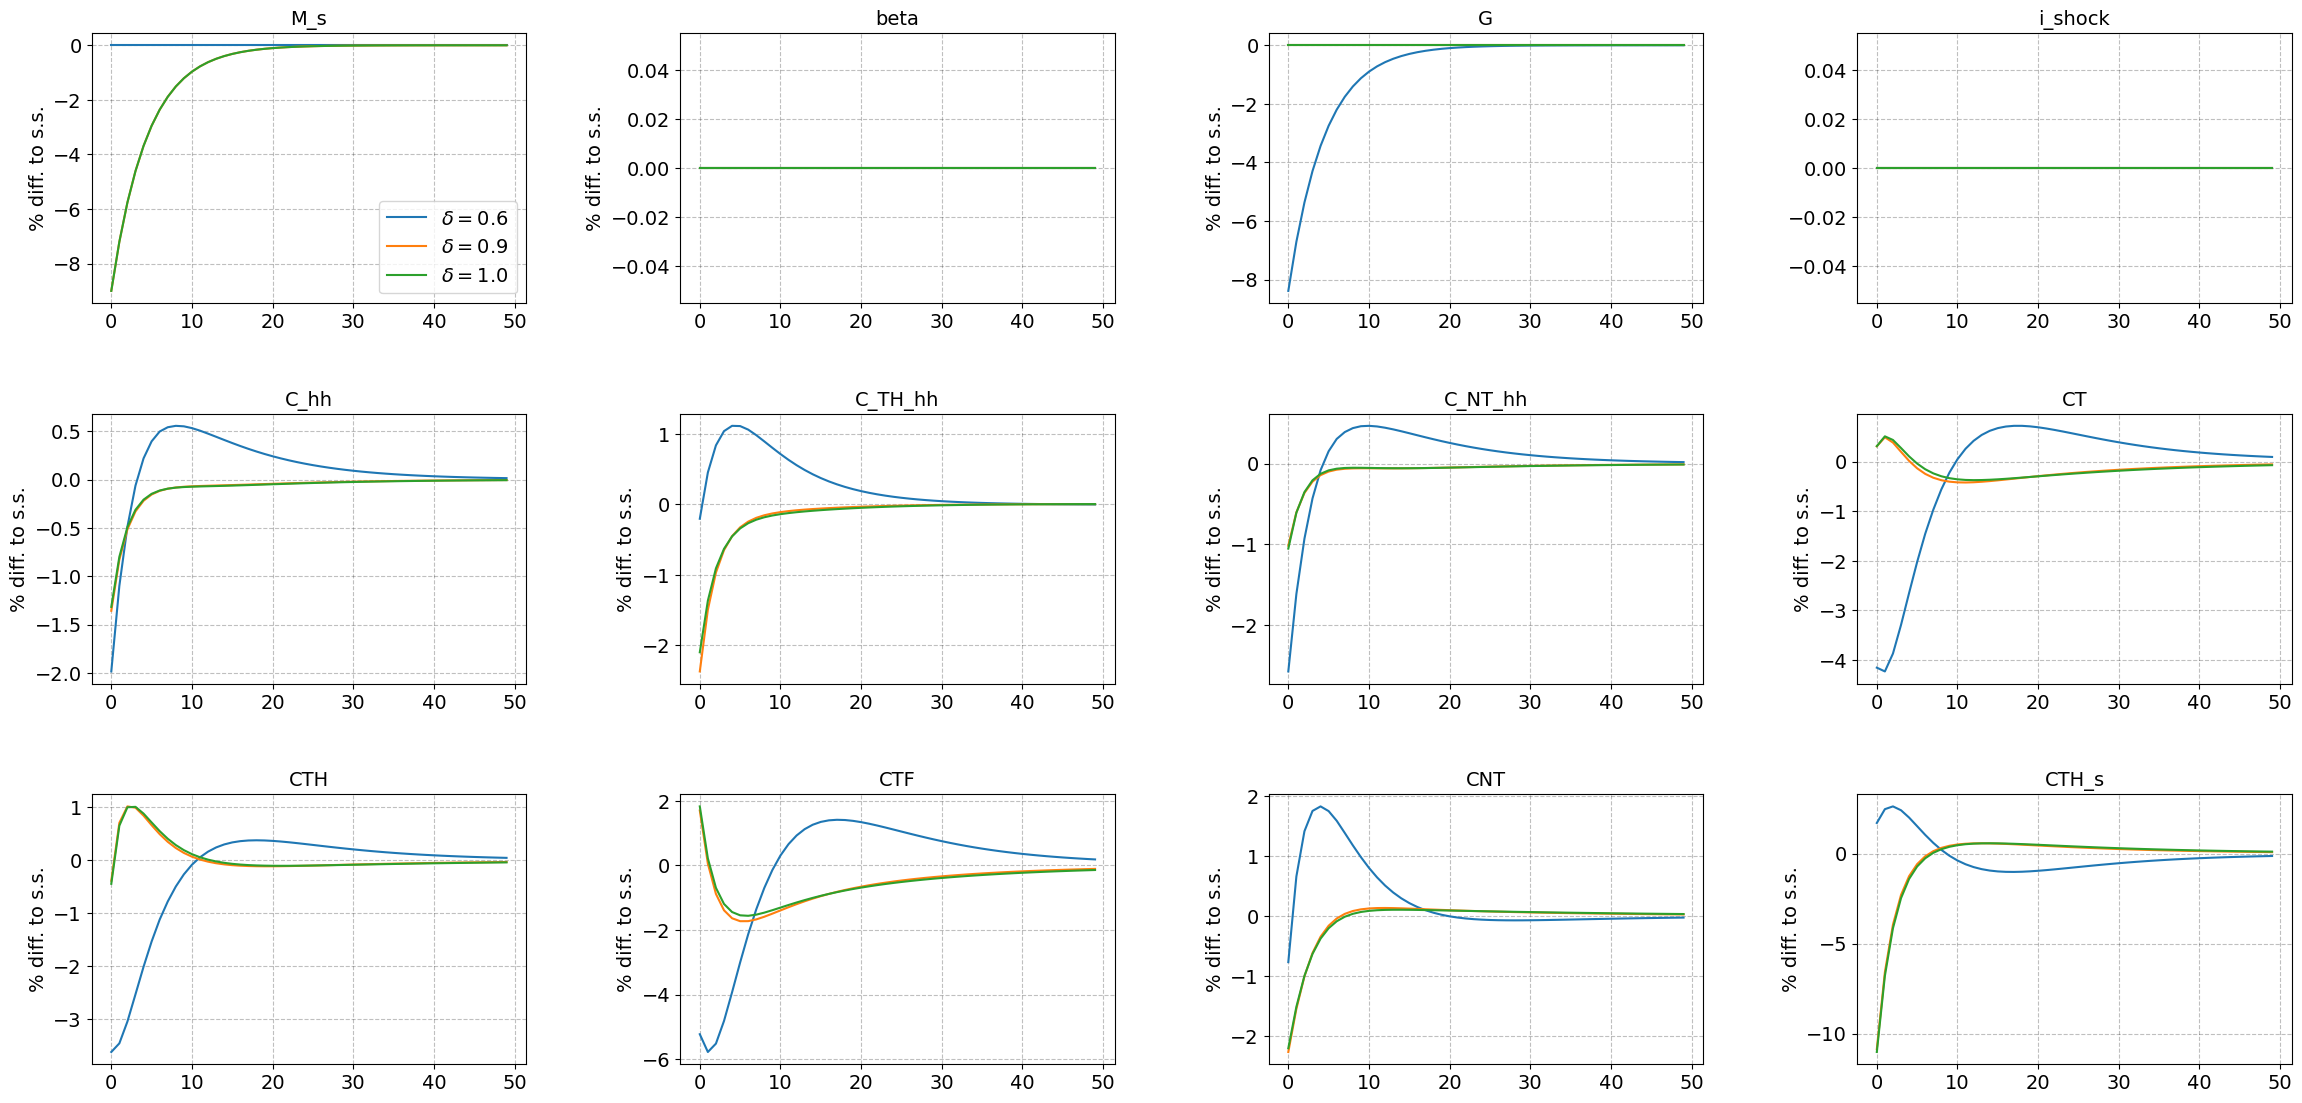

In [21]:
models = [model,PBsmall,ExpoDisc]
labels = ['$\delta = 0.6$','$\delta = 0.9 $','$\delta = 1.0 $']
model.compare_IRFs(models,labels,varnames=['M_s','beta','G','i_shock','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CNT','CTH_s'], do_shocks=False,do_targets=False,
        abs_diff=None,lvl_value=['i_shock'],T_max=50)

## 5.1 <a id='toc5_'></a>[Response in consumption Goverment Spending Shock](#toc0_)

In [22]:
model.par.jump_G = -0.025
model.par.rho_G = 0.80 # AR(1) coefficeint

model.find_transition_path(shocks=['G'],do_print=True,do_end_check=False)

ExpoDisc.par.jump_G = -0.025
ExpoDisc.par.rho_G = 0.80 # AR(1) coefficeint

ExpoDisc.find_transition_path(shocks=['G'],do_print=True,do_end_check=False)

PBsmall.par.jump_G = -0.025
PBsmall.par.rho_G = 0.80 # AR(1) coefficeint

PBsmall.find_transition_path(shocks=['G'],do_print=True,do_end_check=False)

finding the transition path:
 it =   0 -> max. abs. error = 2.39e-02
   9.55e-04 in NKWCT_res
   9.55e-04 in NKWCNT_res
   1.33e-03 in clearing_YTH
   2.39e-02 in clearing_YNT
   0.00e+00 in UIP_res
 it =   1 -> max. abs. error = 7.00e-04
   8.42e-05 in NKWCT_res
   7.00e-04 in NKWCNT_res
   6.23e-05 in clearing_YTH
   3.01e-04 in clearing_YNT
   2.49e-04 in UIP_res
 it =   2 -> max. abs. error = 1.70e-05
   3.08e-06 in NKWCT_res
   6.39e-06 in NKWCNT_res
   3.96e-06 in clearing_YTH
   9.90e-06 in clearing_YNT
   1.70e-05 in UIP_res
 it =   3 -> max. abs. error = 2.60e-07
   5.40e-08 in NKWCT_res
   1.77e-07 in NKWCNT_res
   7.49e-08 in clearing_YTH
   2.60e-07 in clearing_YNT
   8.91e-08 in UIP_res
 it =   4 -> max. abs. error = 5.13e-09
   3.86e-09 in NKWCT_res
   5.13e-09 in NKWCNT_res
   2.99e-09 in clearing_YTH
   4.95e-09 in clearing_YNT
   2.77e-09 in UIP_res
 it =   5 -> max. abs. error = 1.92e-10
   9.09e-11 in NKWCT_res
   1.38e-10 in NKWCNT_res
   4.13e-11 in clearing_YTH
  

c:\users\magnu\onedrive - university of copenhagen\heterogenous agent models\gemodeltools\GEModelTools\figures.py:107: RuntimeWarning: divide by zero encountered in divide
  ax.plot(np.arange(T_max),100*(pathvalue[:T_max]/ssvalue-1),label=label)


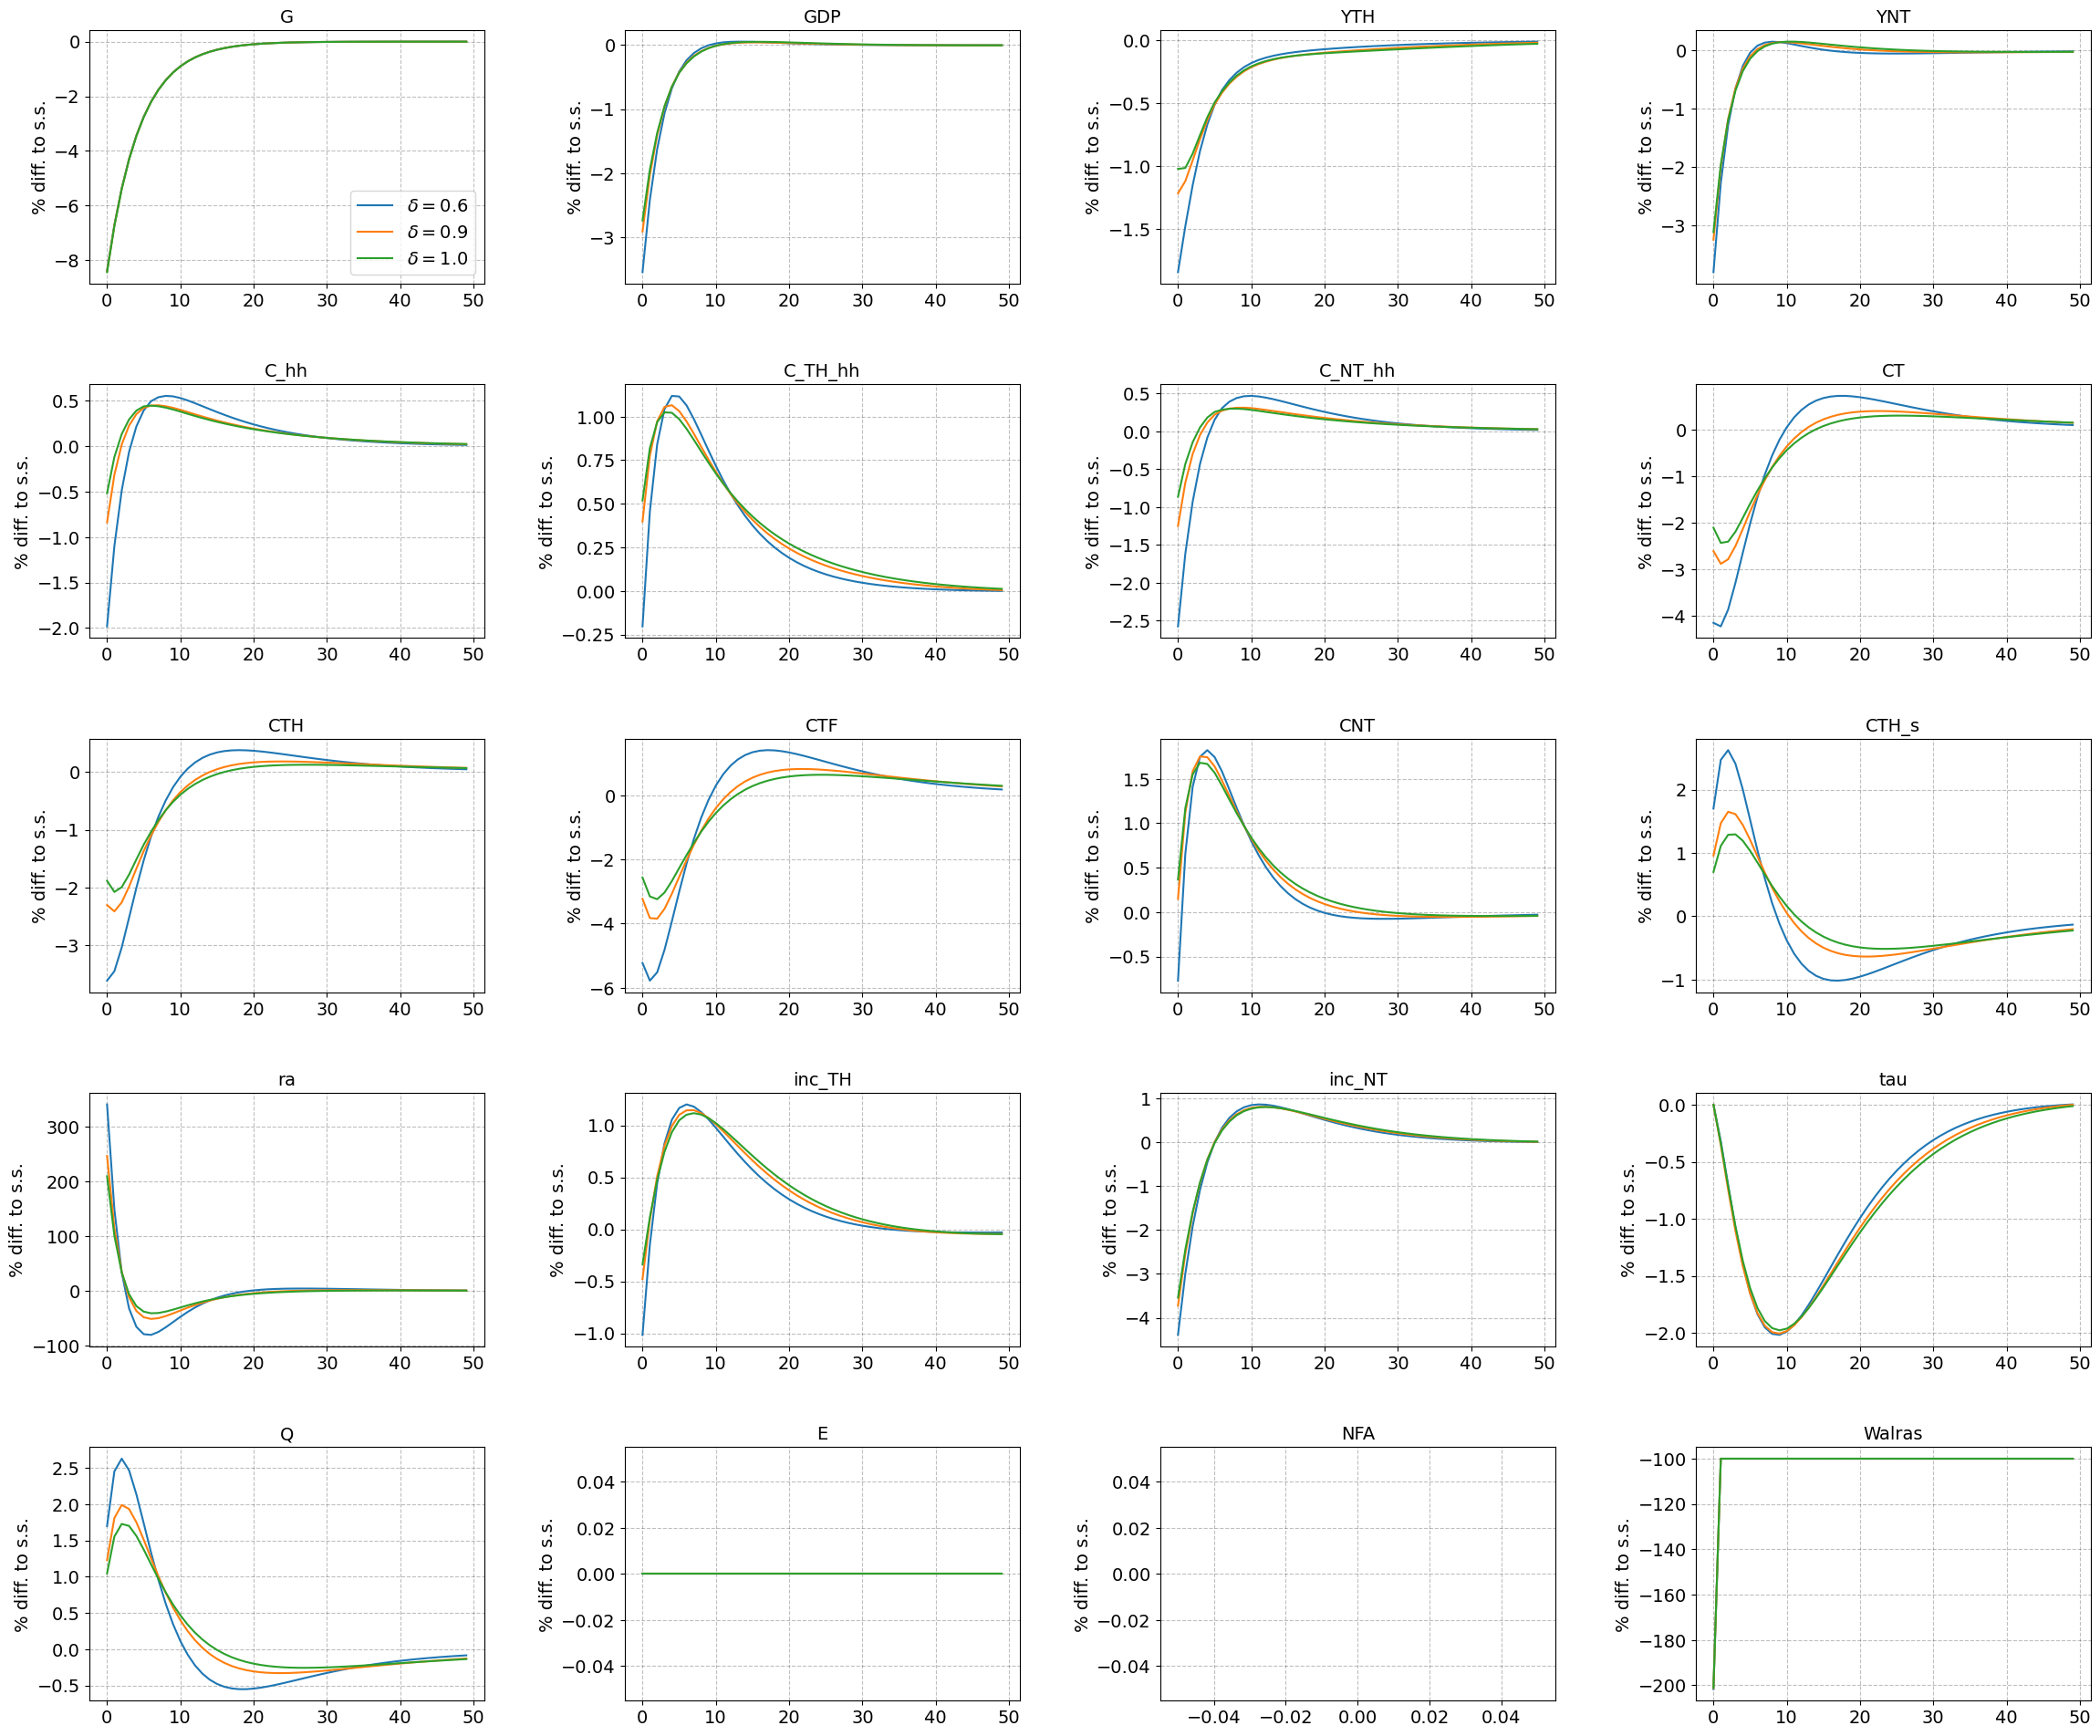

In [23]:
models = [model,PBsmall,ExpoDisc]
labels = ['$\delta = 0.6$','$\delta = 0.9 $','$\delta = 1.0 $']
model.compare_IRFs(models,labels,varnames=['G','GDP','YTH','YNT','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CNT','CTH_s','ra','inc_TH','inc_NT','tau','Q','E','NFA','Walras'], do_shocks=False,do_targets=False,
        abs_diff=None,lvl_value=['i_shock'],T_max=50)

## 5.2 <a id='toc5_'></a>[Response in consumption to different shocks](#toc0_)

Foreign demand shock:

In [24]:
M_s = model.copy()
M_s.par.jump_M_s = -0.0075 # initial jump
M_s.par.rho_M_s = 0.80 # AR(1) coefficeint

M_s.par.jump_rF = -0.00005 # initial jump
M_s.par.rho_rF = 0.80 # AR(1) coefficeint

M_s.par.jump_PF_s = -0.03 # initial jump
M_s.par.rho_PF_s = 0.80 # AR(1) coefficeint

M_s.find_transition_path(shocks=['M_s','rF','PF_s'],do_print=False,do_end_check=False)

Domestic Beta shock:

In [25]:
beta = model.copy()
beta.par.jump_beta = 0.01 # initial jump
beta.par.rho_beta = 0.80 # AR(1) coefficeint

beta.find_transition_path(shocks=['beta'],do_print=False,do_end_check=False)

Domestic G shock:

In [26]:
G = model.copy()
G.par.jump_G = -0.025 # initial jump
G.par.rho_G = 0.80 # AR(1) coefficeint

G.find_transition_path(shocks=['G'],do_print=False,do_end_check=False)

Domestic i shock:

In [27]:
i_shock = model.copy()
i_shock.par.jump_i_shock = 0.01 # initial jump
i_shock.par.rho_i_shock = 0.80 # AR(1) coefficeint

i_shock.find_transition_path(shocks=['i_shock'],do_print=False,do_end_check=False)

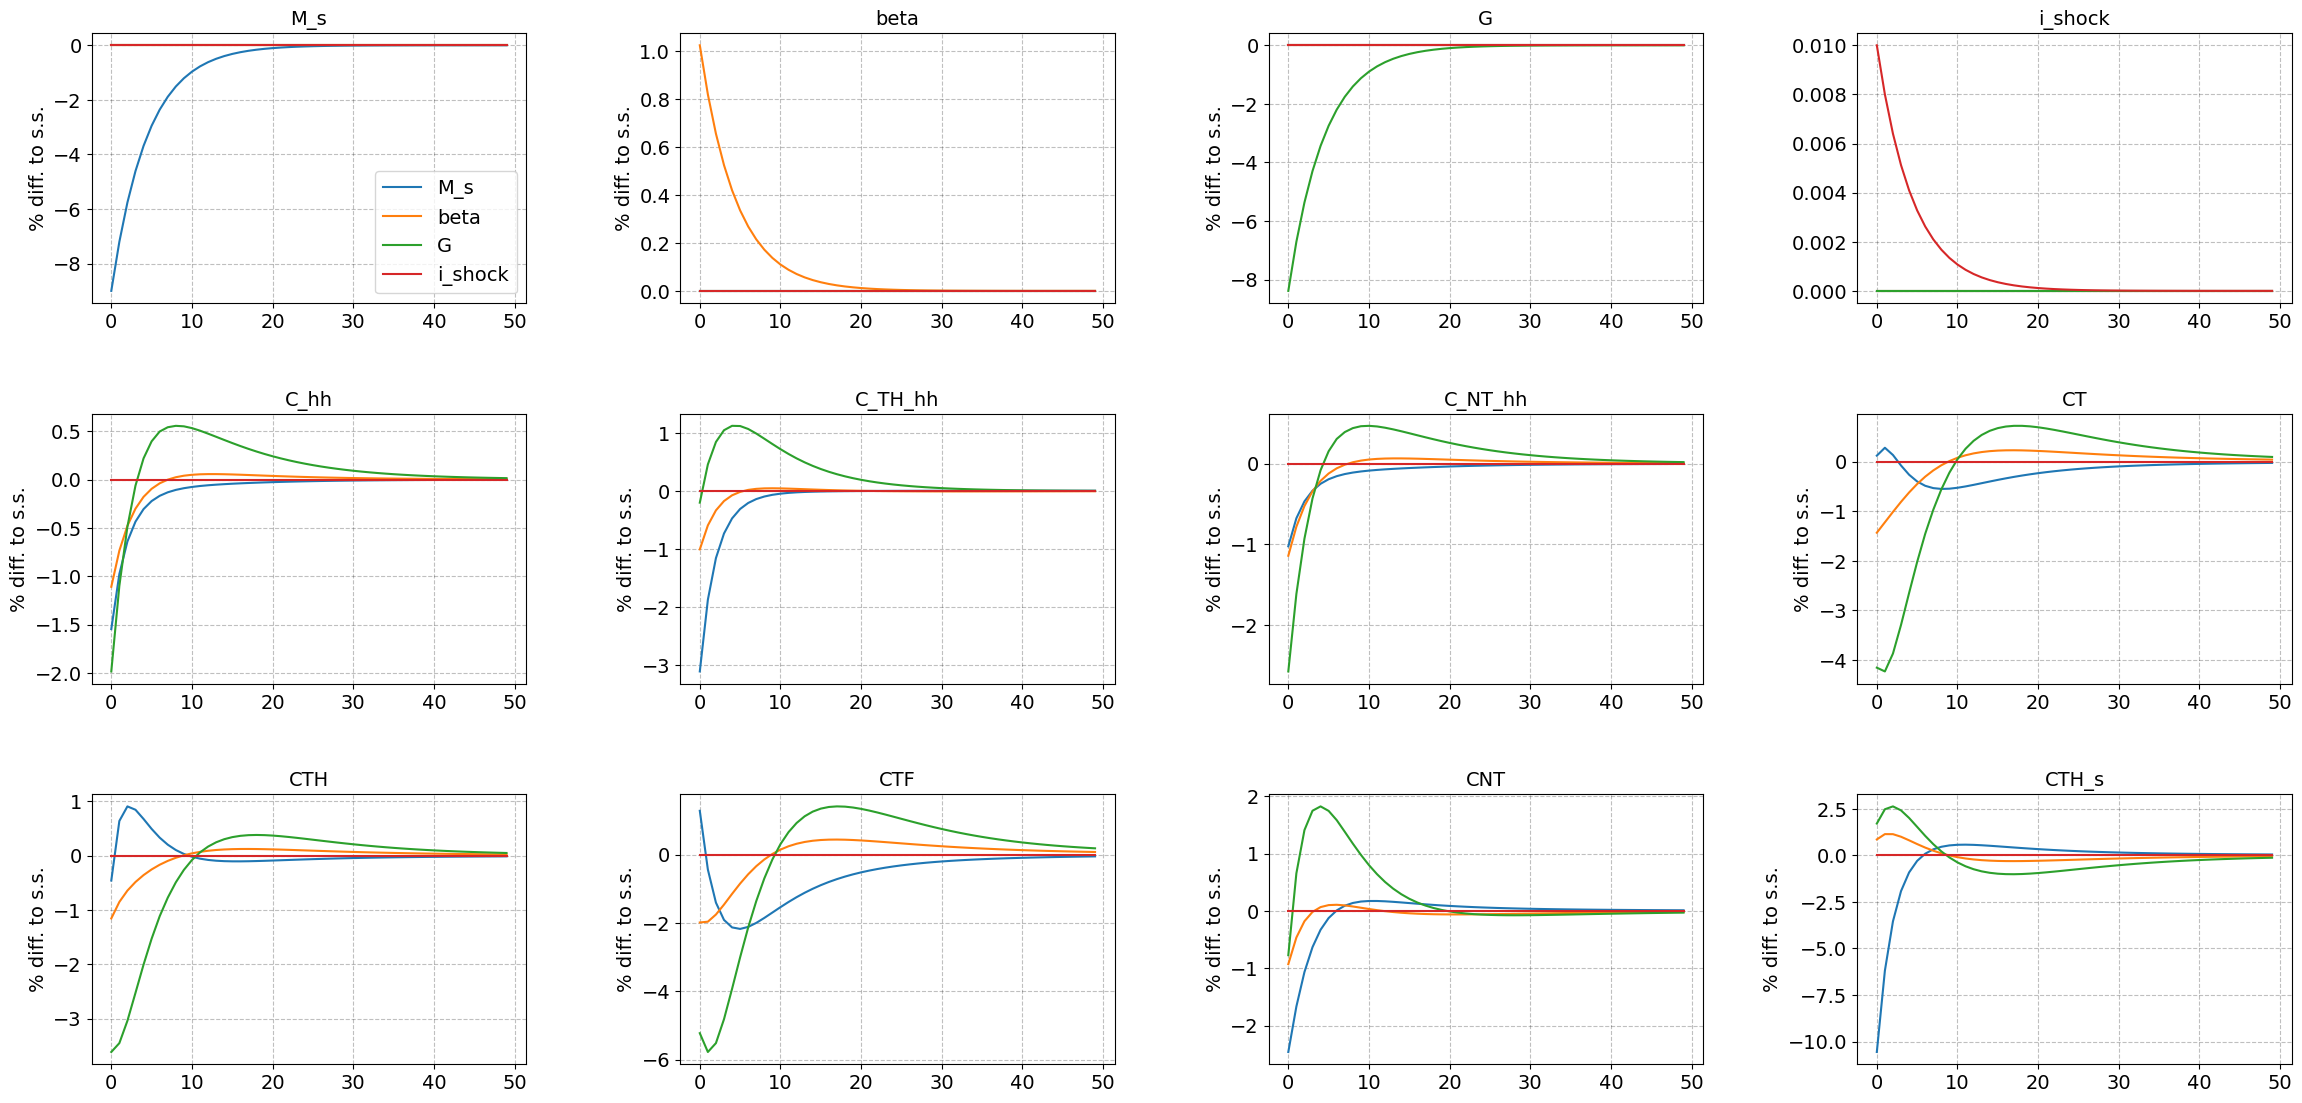

In [28]:
models = [M_s,beta,G,i_shock]
labels = ['M_s','beta','G','i_shock']
model.compare_IRFs(models,labels,varnames=['M_s','beta','G','i_shock','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CNT','CTH_s'], do_shocks=False,do_targets=False,
        abs_diff=None,lvl_value=['i_shock'],T_max=50)

## 6. <a id='toc6_'></a>[Decomposing consumption response](#toc0_)

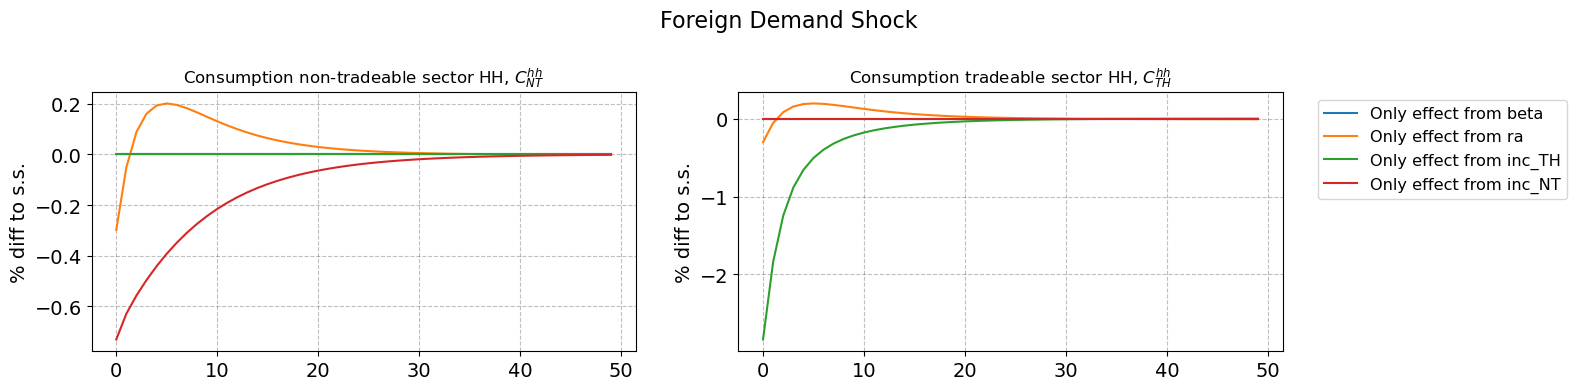

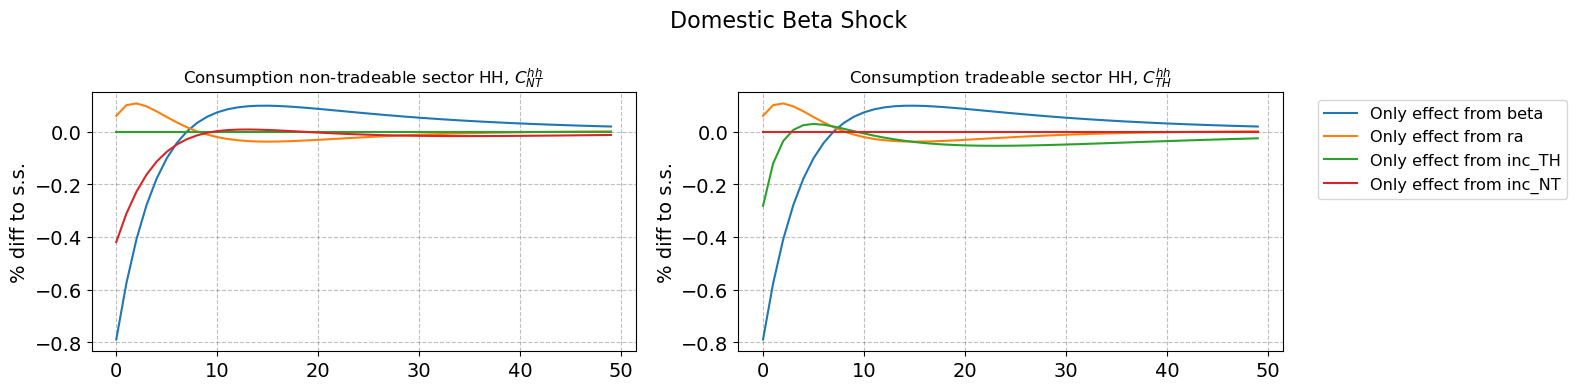

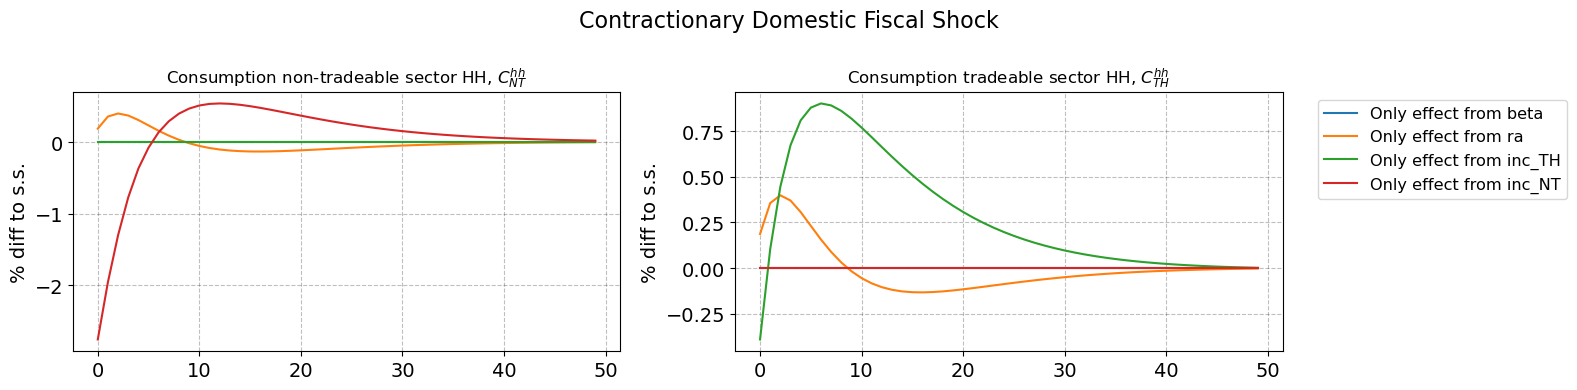

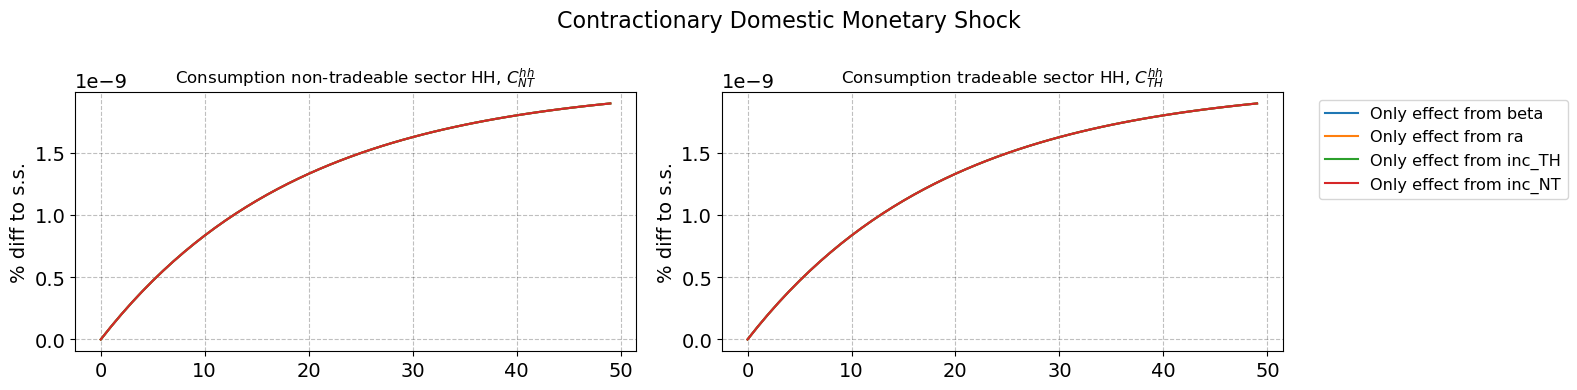

In [29]:
models = {'M_s': M_s, 'beta': beta, 'G': G, 'i_shock': i_shock}

model_titles = {
    'M_s': 'Foreign Demand Shock',
    'beta': 'Domestic Beta Shock',
    'G': 'Contractionary Domestic Fiscal Shock',
    'i_shock': 'Contractionary Domestic Monetary Shock'
}

for model_name, model in models.items():

    T_max = 50

    fig, (ax_C_NT, ax_C_TH) = plt.subplots(1, 2, figsize=(16, 4), dpi=100)
    fig.suptitle(f'{model_titles[model_name]}', fontsize=16)

    ax_C_NT.set_title('Consumption non-tradeable sector HH, $C_{NT}^{hh}$', fontsize=12)
    ax_C_TH.set_title('Consumption tradeable sector HH, $C_{TH}^{hh}$', fontsize=12)

    i_color = 0

    for use_inputs in [[x] for x in model.inputs_hh]:

        # a. compute
        path_alt = model.decompose_hh_path(do_print=False, use_inputs=use_inputs)

        # b. plot
        if use_inputs is None:
            label = 'No inputs'
            ls = '--'
            color = 'black'
        elif use_inputs == 'all':
            label = 'All inputs'
            ls = '-'
            color = 'black'
        else:
            label = f'Only effect from {use_inputs[0]}'
            ls = '-'
            color = f'C{i_color}' # use color index directly
            i_color += 1

        ax_C_NT.plot((path_alt.C_NT_hh[:T_max] / ss.C_NT_hh - 1) * 100, ls=ls, color=color, label=label)
        ax_C_TH.plot((path_alt.C_TH_hh[:T_max] / ss.C_TH_hh - 1) * 100, ls=ls, color=color, label=label)

    for ax in [ax_C_NT, ax_C_TH]:
        ax.set_ylabel('% diff to s.s.')
        lgd = ax_C_TH.legend(frameon=True, ncol=1, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

    plt.tight_layout()  # Adjust layout to prevent overlapping
    plt.show()


## 7. <a id='toc7_'></a>[Fixed vs floating exchange rate](#toc0_)

In [30]:
fixed = model.copy()
fixed.par.float = False
fixed.find_ss()
fixed.compute_jacs()

Foreign demand shock:

In [39]:
M_s_fixed = fixed.copy()
M_s_fixed.par.jump_M_s = -0.0075 # initial jump
M_s_fixed.par.rho_M_s = 0.80 # AR(1) coefficeint

M_s_fixed.par.jump_rF = -0.00005 # initial jump
M_s_fixed.par.rho_rF = 0.80 # AR(1) coefficeint

M_s_fixed.par.jump_PF_s = -0.03 # initial jump
M_s_fixed.par.rho_PF_s = 0.80 # AR(1) coefficeint

M_s_fixed.find_transition_path(shocks=['M_s','rF','PF_s'])

In [ ]:
models = [M_s,M_s_fixed]
labels = ['floating','fixed']
model.compare_IRFs(models,labels,varnames=['M_s','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CNT','CTH_s','i','E'], do_shocks=False,do_targets=False,
        abs_diff=None,lvl_value=['i_shock','pi'],T_max=50)

Domestic beta shock:

In [27]:
beta_fixed = fixed.copy()
beta_fixed.par.jump_beta = 0.01 # initial jump
beta_fixed.par.rho_beta = 0.80 # AR(1) coefficeint

beta_fixed.find_transition_path(shocks=['beta'])

In [ ]:
models = [beta,beta_fixed]
labels = ['floating','fixed']
model.compare_IRFs(models,labels,varnames=['beta','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CNT','CTH_s','i','E'], do_shocks=False,do_targets=False,
        abs_diff=None,lvl_value=['i_shock'],T_max=50)

Domestic G shock:

In [29]:
G_fixed = fixed.copy()
G_fixed.par.jump_G = -0.025 # initial jump
G_fixed.par.rho_G = 0.80 # AR(1) coefficeint

G_fixed.find_transition_path(shocks=['G'])

In [ ]:
models = [G,G_fixed]
labels = ['floating','fixed']
model.compare_IRFs(models,labels,varnames=['G','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CNT','CTH_s','i','E'], do_shocks=False,do_targets=False,
        abs_diff=None,lvl_value=['i_shock'],T_max=50)

## 8. <a id='toc8_'></a>[Decomposing consumption response under fixed exchange rate](#toc0_)

In [ ]:
models = {'M_s': M_s_fixed, 'beta': beta_fixed, 'G': G_fixed}

model_titles = {
    'M_s': 'Foreign Demand Shock',
    'beta': 'Domestic Beta Shock',
    'G': 'Contractionary Domestic Fiscal Shock'   
}

for model_name, model in models.items():

    T_max = 50

    fig, (ax_C_NT, ax_C_TH) = plt.subplots(1, 2, figsize=(16, 4), dpi=100)
    fig.suptitle(f'{model_titles[model_name]}', fontsize=16)

    ax_C_NT.set_title('Consumption non-tradeable sector HH, $C_{NT}^{hh}$', fontsize=12)
    ax_C_TH.set_title('Consumption tradeable sector HH, $C_{TH}^{hh}$', fontsize=12)

    i_color = 0

    for use_inputs in [[x] for x in model.inputs_hh]:

        # a. compute
        path_alt = model.decompose_hh_path(do_print=False, use_inputs=use_inputs)

        # b. plot
        if use_inputs is None:
            label = 'No inputs'
            ls = '--'
            color = 'black'
        elif use_inputs == 'all':
            label = 'All inputs'
            ls = '-'
            color = 'black'
        else:
            label = f'Only effect from {use_inputs[0]}'
            ls = '-'
            color = f'C{i_color}' # use color index directly
            i_color += 1

        ax_C_NT.plot((path_alt.C_NT_hh[:T_max] / ss.C_NT_hh - 1) * 100, ls=ls, color=color, label=label)
        ax_C_TH.plot((path_alt.C_TH_hh[:T_max] / ss.C_TH_hh - 1) * 100, ls=ls, color=color, label=label)

    for ax in [ax_C_NT, ax_C_TH]:
        ax.set_ylabel('% diff to s.s.')
        lgd = ax_C_TH.legend(frameon=True, ncol=1, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

    plt.tight_layout()  # Adjust layout to prevent overlapping
    plt.show()
